# ?? Task 1: RetailPulse Forecast ? Sales & Demand Forecasting for Businesses
### Track: Machine Learning (`ML`) | Internship ID: `FIT/AUG26/ML10465` | Repository: `FUTURE_ML_01`

---
### **Project Overview & Objectives**
In enterprise retail operations, demand forecasting errors drive high-cost inventory inefficiencies: stockouts during holiday surges lead to lost revenue and customer churn, while post-holiday overstocking causes holding depreciation and markdown losses.

**RetailPulse Forecast** is an enterprise Machine Learning forecasting and decision-support pipeline built with strict temporal validation standards:

#### **Key Methodology & Architecture:**
1. **Zero Look-Ahead Leakage**: All lag features ($t-1, t-2, t-4, t-8, t-12, t-52$) and rolling window aggregates ($4, 8, 12, 26, 52$ weeks) are shifted strictly within each Store/Department time-series.
2. **Rigorous Chronological 3-Way Split**:
   - **70% Training Horizon**: Used strictly to fit model weights.
   - **15% Validation Horizon**: Used for candidate model benchmarking and **Champion Model Selection**.
   - **15% Out-of-Time Test Horizon**: Kept strictly untouched until final evaluation of the validation-selected champion.
3. **Statistical Uncertainty Quantification**: $95\%$ empirical prediction interval calculated directly at the aggregate weekly level using validation aggregate residual standard deviation ($\hat{Y}_{\text{agg}} \pm 1.96 \cdot \sigma_{\text{agg}, \text{val}}$).
4. **Lead-Time Inventory Policy Translation**: Safety Stock and Dynamic Reorder Point (ROP) calculation at a 95% Service Level Agreement ($Z_{0.95} = 1.645$) using weekly error standard deviation scaled by $\sqrt{L}$ for lead time $L = 2$ weeks.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

sys.path.append(os.path.abspath('..'))

from src.data_loader import save_and_load_dataset
from src.features import create_time_features, create_lag_and_rolling_features, prepare_feature_matrix
from src.models import get_model_registry, chronological_split
from src.evaluate import compute_metrics, analyze_error_by_segment

print("? RetailPulse environment loaded. Python version:", sys.version.split()[0])

? RetailPulse environment loaded. Python version: 3.12.5


## 1. Data Ingestion & Time-Series Exploration

In [2]:
data_path = os.path.join('..', 'data', 'retail_store_sales.csv')
df = save_and_load_dataset(data_path)
print("Dataset Shape:", df.shape)
display(df.head(10))
display(df.describe().round(2))

[DataLoader] Dataset loaded from ..\data\retail_store_sales.csv (Shape: (5490, 15))
Dataset Shape: (5490, 15)


,Date,Store_ID,Store_Type,Store_Size,Dept_ID,Dept_Name,Weekly_Sales,IsHoliday,Holiday_Name,Markdown_Discount,Promotional_Flag,Temperature,Fuel_Price,CPI,Unemployment_Rate
0,2021-01-01,1,A,150000,1,Electronics,48356.88,0,NaN,0.00,0,35.7,3.139,210.248,7.52
1,2021-01-08,1,A,150000,1,Electronics,48052.62,0,NaN,0.00,0,44.5,3.144,210.068,7.49
2,2021-01-15,1,A,150000,1,Electronics,49517.76,0,NaN,1154.62,1,36.4,3.281,210.599,7.49
3,2021-01-22,1,A,150000,1,Electronics,42339.50,0,NaN,0.00,0,36.5,3.323,211.174,7.39
4,2021-01-29,1,A,150000,1,Electronics,50128.12,0,NaN,0.00,0,40.1,3.340,210.432,7.45
5,2021-02-05,1,A,150000,1,Electronics,45891.73,0,NaN,0.00,0,37.8,3.337,210.570,7.49
6,2021-02-12,1,A,150000,1,Electronics,55328.80,1,Super Bowl,1705.51,1,31.6,3.341,211.614,7.57
7,2021-02-19,1,A,150000,1,Electronics,46959.04,0,NaN,0.00,0,48.6,3.483,211.345,7.51
8,2021-02-26,1,A,150000,1,Electronics,48078.43,0,NaN,0.00,0,46.8,3.641,210.864,7.62
9,2021-03-05,1,A,150000,1,Electronics,48593.30,0,NaN,4259.33,1,48.5,3.641,211.508,7.31


,Date,Store_ID,Store_Size,Dept_ID,Weekly_Sales,IsHoliday,Markdown_Discount,Promotional_Flag,Temperature,Fuel_Price,CPI,Unemployment_Rate
count,5490,5490.00,5490.00,5490.00,5490.00,5490.00,5490.00,5490.00,5490.00,5490.00,5490.00,5490.00
mean,2022-09-30 00:00:00,3.00,103000.00,3.50,29674.31,0.13,785.28,0.32,59.51,3.10,222.49,6.39
min,2021-01-01 00:00:00,1.00,50000.00,1.00,2975.02,0.00,0.00,0.00,24.80,2.10,210.07,5.10
25%,2021-11-12 00:00:00,2.00,85000.00,2.00,11799.81,0.00,0.00,0.00,44.52,2.45,215.85,5.79
50%,2022-09-30 00:00:00,3.00,90000.00,3.50,21516.01,0.00,0.00,0.00,59.10,3.09,222.41,6.36
75%,2023-08-18 00:00:00,4.00,140000.00,5.00,39873.24,0.00,1333.29,1.00,74.80,3.73,228.66,6.99
max,2024-06-28 00:00:00,5.00,150000.00,6.00,198654.61,1.00,4498.02,1.00,93.30,4.29,235.95,7.62
std,NaN,1.41,37097.85,1.71,25691.95,0.33,1321.63,0.47,16.10,0.65,7.32,0.66


### 1.1 Historical Aggregate Demand Trajectory

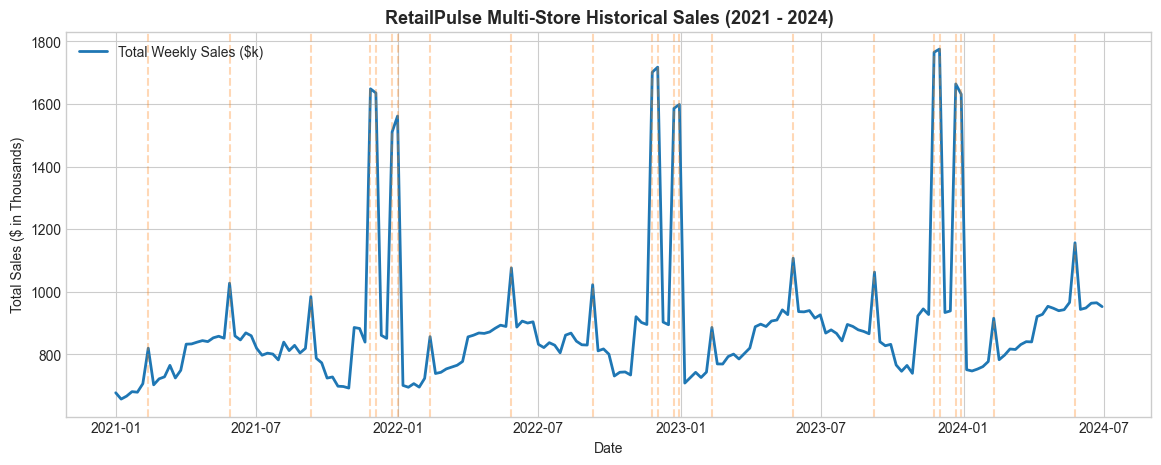

In [3]:
plt.figure(figsize=(14, 5))
weekly_agg = df.groupby("Date")["Weekly_Sales"].sum().reset_index()
plt.plot(weekly_agg["Date"], weekly_agg["Weekly_Sales"] / 1e3, color="#1f77b4", lw=2, label="Total Weekly Sales ($k)")
holidays = df[df["IsHoliday"] == 1]["Date"].unique()
for h in holidays:
    plt.axvline(pd.to_datetime(h), color="#ff7f0e", linestyle="--", alpha=0.3)
plt.title("RetailPulse Multi-Store Historical Sales (2021 - 2024)", fontsize=13, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Total Sales ($ in Thousands)")
plt.legend()
plt.show()

## 2. Time-Based Feature Engineering & Leakage Verification

In [4]:
df_feat, feature_cols = prepare_feature_matrix(df)
print(f"Total engineered features: {len(feature_cols)}")
print("Sample feature columns:", feature_cols[:12])
print("Processed feature matrix shape (after 52W lag alignment):", df_feat.shape)

Total engineered features: 57
Sample feature columns: ['Store_ID', 'Store_Size', 'Dept_ID', 'IsHoliday', 'Markdown_Discount', 'Promotional_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment_Rate', 'Year', 'Month']
Processed feature matrix shape (after 52W lag alignment): (3930, 60)


## 3. Chronological 3-Way Train/Validation/Test Split

In [5]:
df_train, df_val, df_test = chronological_split(df_feat, train_ratio=0.70, val_ratio=0.15)
X_train, y_train = df_train[feature_cols], df_train["Weekly_Sales"]
X_val, y_val = df_val[feature_cols], df_val["Weekly_Sales"]
X_test, y_test = df_test[feature_cols], df_test["Weekly_Sales"]

print(f"Train samples (70%):      {len(df_train)} | {df_train['Date'].min().date()} to {df_train['Date'].max().date()}")
print(f"Validation samples (15%): {len(df_val)}   | {df_val['Date'].min().date()} to {df_val['Date'].max().date()}")
print(f"Test samples (15%):       {len(df_test)}  | {df_test['Date'].min().date()} to {df_test['Date'].max().date()}")

Train samples (70%):      2730 | 2021-12-31 to 2023-09-22
Validation samples (15%): 600   | 2023-09-29 to 2024-02-09
Test samples (15%):       600  | 2024-02-16 to 2024-06-28


## 4. Model Training & Champion Selection on VALIDATION Set

In [6]:
registry = get_model_registry()
val_results = []
val_predictions = {}
trained_models = {}

for name, model in registry.items():
    # Fit exclusively on training data
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    # Evaluate strictly on validation set for model selection
    y_val_pred = np.maximum(0, model.predict(X_val))
    val_predictions[name] = y_val_pred
    m = compute_metrics(y_val, y_val_pred)
    m["Model"] = name
    val_results.append(m)

val_df = pd.DataFrame(val_results)[["Model", "MAE ($)", "RMSE ($)", "MAPE (%)", "WAPE (%)", "R2 Score"]]
val_df = val_df.sort_values(by="WAPE (%)").reset_index(drop=True)

# Select Champion Model ONLY based on lowest validation WAPE
champion_name = val_df.iloc[0]["Model"]
champion_val_wape = val_df.iloc[0]["WAPE (%)"]
champion_model = trained_models[champion_name]

# Compute aggregate weekly validation residual standard deviation
df_val_eval = df_val.copy()
df_val_eval["Predicted_Sales"] = val_predictions[champion_name]
val_agg = df_val_eval.groupby("Date").agg({"Weekly_Sales": "sum", "Predicted_Sales": "sum"}).reset_index()
val_agg_residual_std = float(np.std(val_agg["Weekly_Sales"] - val_agg["Predicted_Sales"], ddof=1))

print(f"?? CHAMPION MODEL SELECTED: {champion_name} (Validation WAPE: {champion_val_wape:.2f}%)")
print(f"Validation Aggregate Residual Standard Deviation (sigma_agg_val): ${val_agg_residual_std:,.2f}")
display(val_df.style.highlight_min(subset=["MAE ($)", "RMSE ($)", "WAPE (%)"], color="#c7e9c0"))

?? CHAMPION MODEL SELECTED: XGBoost Regressor (Validation WAPE: 5.65%)
Validation Aggregate Residual Standard Deviation (sigma_agg_val): $33,820.44


,Model,MAE ($),RMSE ($),MAPE (%),WAPE (%),R2 Score
0,XGBoost Regressor,1887.080000,3816.870000,5.490000,5.650000,0.984600
1,Random Forest,1897.250000,3531.830000,5.540000,5.680000,0.986800
2,Seasonal Lag-52,1986.590000,3433.090000,5.890000,5.940000,0.987600
3,LightGBM Regressor,2083.720000,4576.860000,5.710000,6.230000,0.977900
4,Ridge Regression,2846.070000,4630.250000,11.220000,8.510000,0.977400
5,Naive Lag-1,7404.300000,16884.410000,21.580000,22.150000,0.699200
6,Rolling 4W Moving Avg,9542.060000,16859.600000,28.850000,28.540000,0.700000


## 5. Unbiased Out-of-Time Final Evaluation on Untouched TEST Set

In [7]:
test_results = []
test_predictions = {}

for name, model in trained_models.items():
    y_test_pred = np.maximum(0, model.predict(X_test))
    test_predictions[name] = y_test_pred
    m = compute_metrics(y_test, y_test_pred)
    m["Model"] = name
    m["Is_Champion"] = (name == champion_name)
    test_results.append(m)

test_df = pd.DataFrame(test_results)[["Model", "Is_Champion", "MAE ($)", "RMSE ($)", "MAPE (%)", "WAPE (%)", "R2 Score"]]
test_df = test_df.sort_values(by="WAPE (%)").reset_index(drop=True)

print("Final Unbiased Test Horizon Evaluation Table:")
display(test_df.style.highlight_min(subset=["MAE ($)", "RMSE ($)", "WAPE (%)"], color="#c7e9c0"))

Final Unbiased Test Horizon Evaluation Table:

,Model,Is_Champion,MAE ($),RMSE ($),MAPE (%),WAPE (%),R2 Score
0,Random Forest,False,1369.860000,2161.700000,4.800000,4.500000,0.992300
1,XGBoost Regressor,True,1384.250000,2098.710000,4.860000,4.550000,0.992800
2,LightGBM Regressor,False,1519.410000,2483.270000,5.250000,4.990000,0.989900
3,Ridge Regression,False,1650.420000,2327.220000,7.880000,5.430000,0.991100
4,Seasonal Lag-52,False,1738.850000,2661.810000,5.950000,5.720000,0.988400
5,Rolling 4W Moving Avg,False,1996.760000,3474.410000,6.610000,6.560000,0.980200
6,Naive Lag-1,False,2417.930000,4075.670000,8.100000,7.950000,0.972700


## 6. Out-of-Time Forecast Visualizations & Statistical 95% Prediction Interval

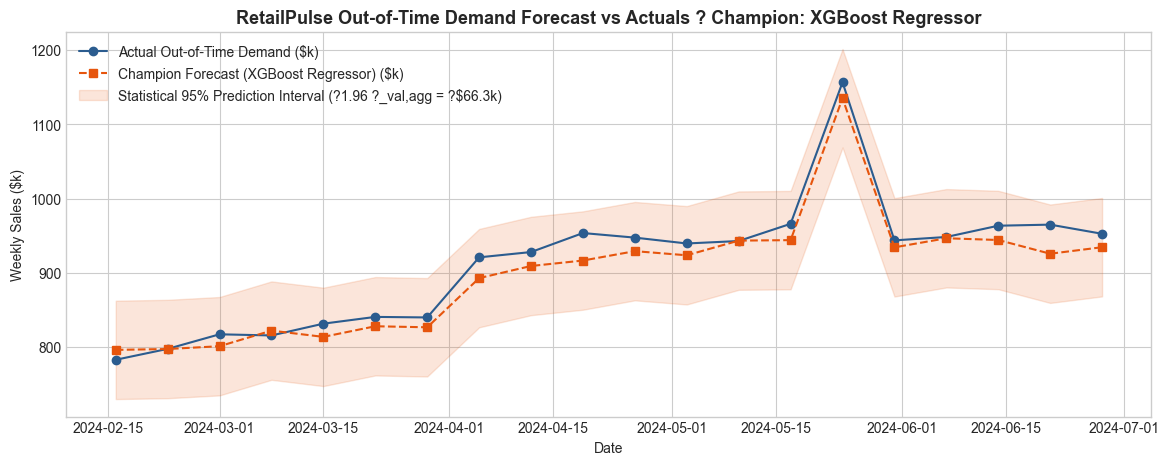

In [8]:
df_test_eval = df_test.copy()
df_test_eval["Predicted_Sales"] = test_predictions[champion_name]

test_agg = df_test_eval.groupby("Date").agg({"Weekly_Sales": "sum", "Predicted_Sales": "sum"}).reset_index()

lower_bound = np.maximum(0, test_agg["Predicted_Sales"] - 1.96 * val_agg_residual_std) / 1e3
upper_bound = (test_agg["Predicted_Sales"] + 1.96 * val_agg_residual_std) / 1e3

plt.figure(figsize=(14, 5))
plt.plot(test_agg["Date"], test_agg["Weekly_Sales"] / 1e3, label="Actual Out-of-Time Demand ($k)", color="#2b5c8f", marker="o")
plt.plot(test_agg["Date"], test_agg["Predicted_Sales"] / 1e3, label=f"Champion Forecast ({champion_name}) ($k)", color="#e6550d", linestyle="--", marker="s")
plt.fill_between(test_agg["Date"], lower_bound, upper_bound, color="#e6550d", alpha=0.15, label=f"Statistical 95% Prediction Interval (?1.96 ?_val,agg = ?${(1.96*val_agg_residual_std/1e3):.1f}k)")
plt.title(f"RetailPulse Out-of-Time Demand Forecast vs Actuals ? Champion: {champion_name}", fontsize=13, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($k)")
plt.legend()
plt.show()

## 7. Business Insights & Dynamic Safety Stock Policy (95% Service Level)

In [9]:
df_test_eval["Residual"] = df_test_eval["Weekly_Sales"] - df_test_eval["Predicted_Sales"]

dept_summary = df_test_eval.groupby("Dept_ID").agg(
    Avg_Weekly_Sales=("Weekly_Sales", "mean"),
    Forecasted_Demand=("Predicted_Sales", "mean"),
    Sigma_Weekly_Error=("Residual", "std")
).reset_index()

lead_time_weeks = 2
z_95 = 1.645 # 95% service level normal quantile

# Safety Stock formula: Z * sigma_weekly * sqrt(L)
dept_summary["Safety_Stock_Buffer ($)"] = (z_95 * dept_summary["Sigma_Weekly_Error"] * np.sqrt(lead_time_weeks)).round(2)
dept_summary["Reorder_Point_ROP ($)"] = ((dept_summary["Forecasted_Demand"] * lead_time_weeks) + dept_summary["Safety_Stock_Buffer ($)"]).round(2)

dept_names = {1: "Electronics", 2: "Apparel", 3: "Grocery", 4: "Home & Garden", 5: "Toys", 6: "Health & Beauty"}
dept_summary["Department"] = dept_summary["Dept_ID"].map(dept_names)

print("Statistical Inventory Policy Summary (95% Service Level, L=2 Weeks):")
display(dept_summary[["Dept_ID", "Department", "Forecasted_Demand", "Sigma_Weekly_Error", "Safety_Stock_Buffer ($)", "Reorder_Point_ROP ($)"]])

Statistical Inventory Policy Summary (95% Service Level, L=2 Weeks):


,Dept_ID,Department,Forecasted_Demand,Sigma_Weekly_Error,Safety_Stock_Buffer ($),Reorder_Point_ROP ($)
0,1,Electronics,30630.738281,2360.629883,5491.73,66753.21
1,2,Apparel,26377.710938,1501.325768,3492.66,56248.08
2,3,Grocery,61042.679688,3064.087429,7128.24,129213.60
3,4,Home & Garden,23936.050781,1866.273560,4341.66,52213.76
4,5,Toys,14142.634766,1165.064362,2710.38,30995.65
5,6,Health & Beauty,23508.748047,1225.074468,2849.99,49867.49
